In [1]:
#Module imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('data/cleaned_df.csv')

In [4]:
df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Year of study,Department,Parental_Education,Dropout
0,22.1,1,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,1,Arts,High School,0
1,20.7,1,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,3,Engineering,Bachelor,1
2,22.4,1,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,1,Arts,Master,0
3,20.5,0,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,4,Business,Bachelor,0
4,20.5,1,25000.0,1,4.11,89.1,2,47.1,0,1,6.0,2.52,2.72,2.69,3,Business,None,0


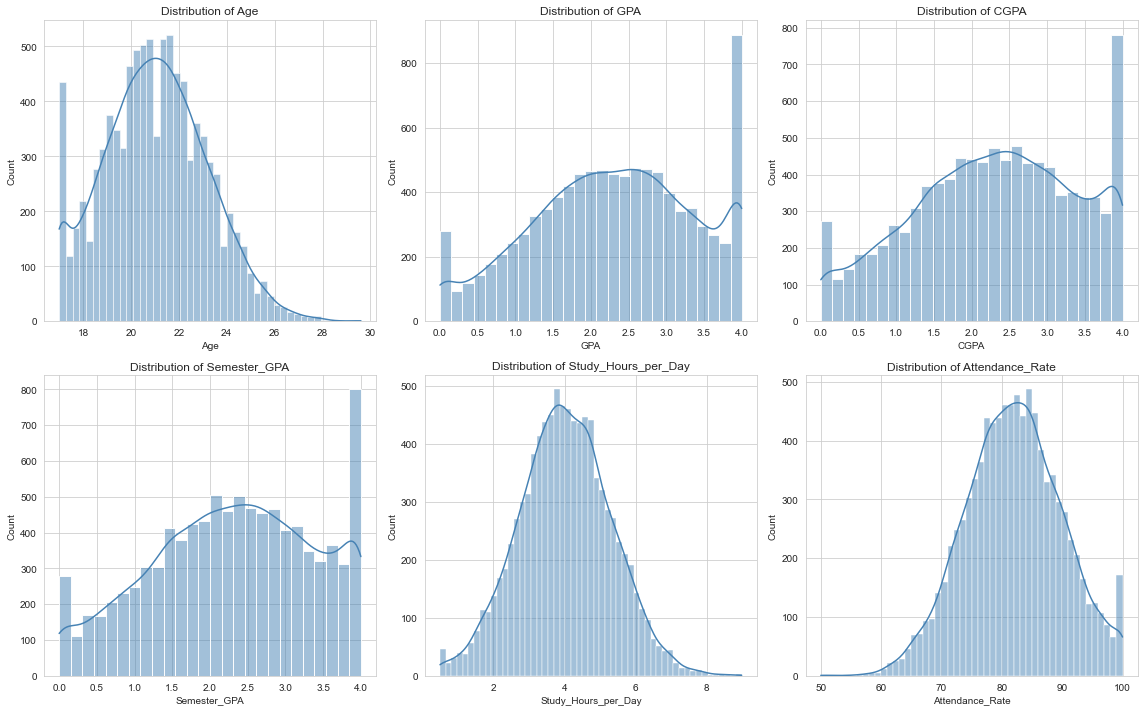

In [5]:
#1. Univariate Analysis — Distribution of Key Numeric Variables

# Set style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

numeric_cols = ['Age', 'GPA', 'CGPA', 'Semester_GPA', 
                'Study_Hours_per_Day', 'Attendance_Rate']

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

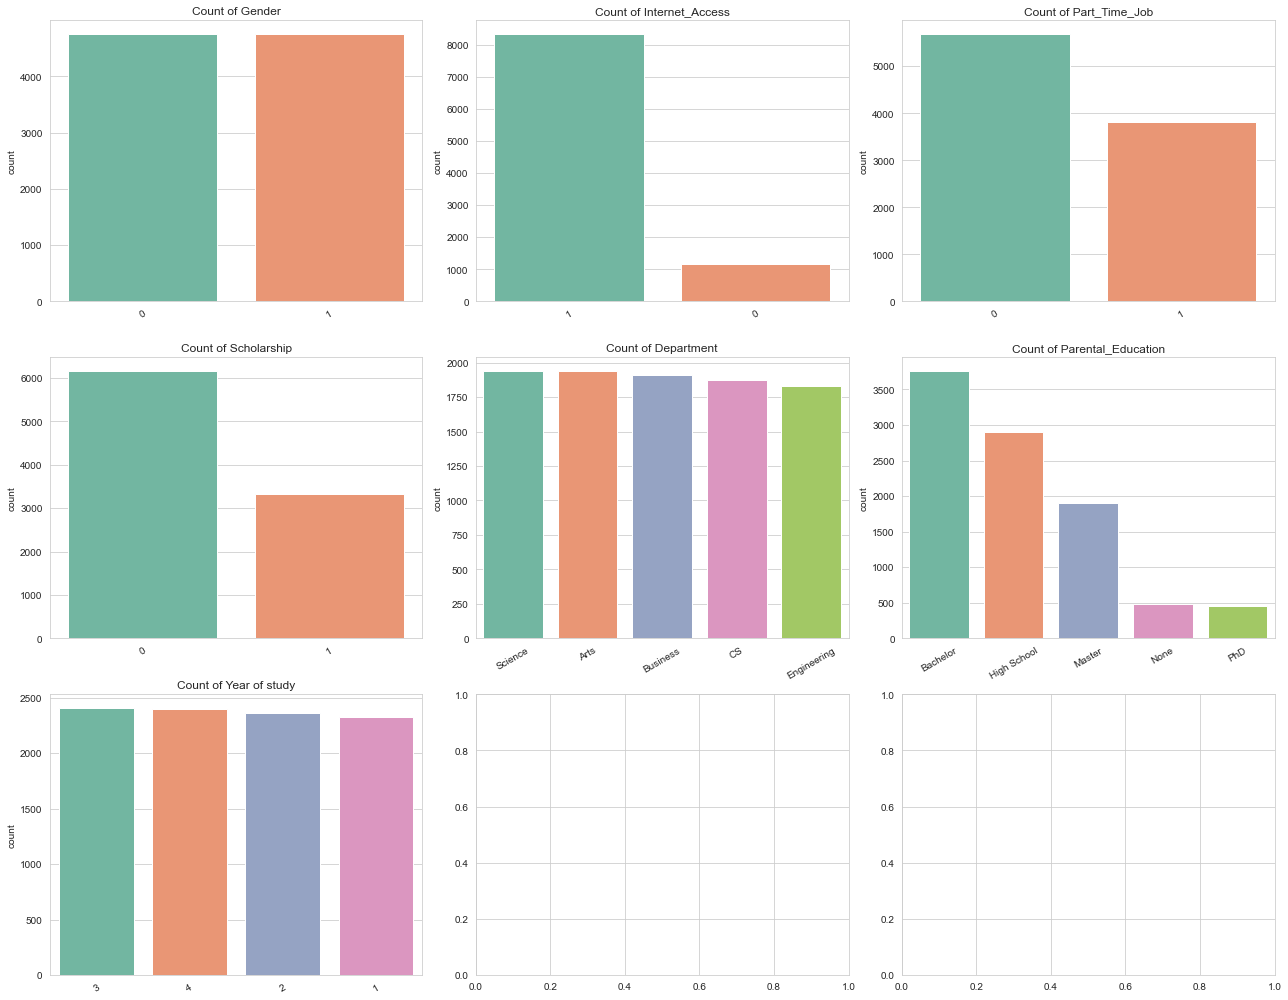

In [ ]:
#Categorical Variable Counts
cat_cols = ['Gender', 'Internet_Access', 'Part_Time_Job', 
            'Scholarship', 'Department', 'Parental_Education', 'Year of study']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=ax, order=order, palette='Set2')
    ax.set_title(f'Count of {col}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

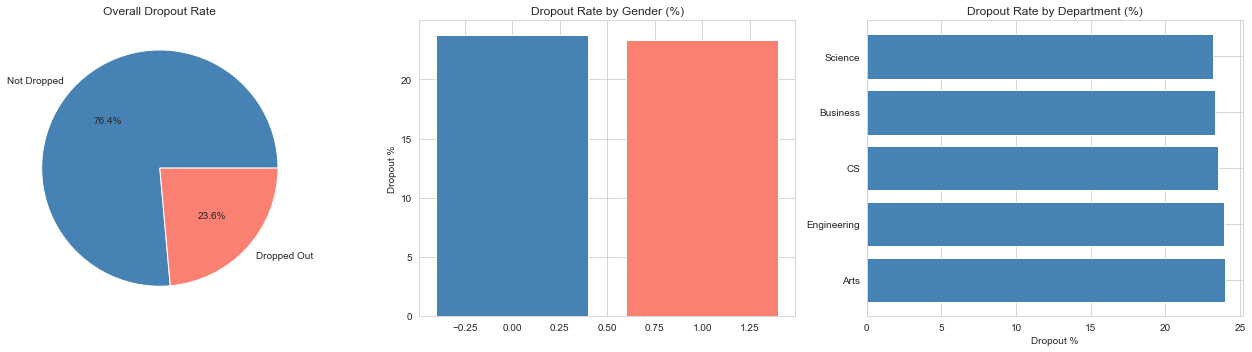

In [10]:
#Dropout Analysis bu Gender and Department
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall dropout rate
dropout_pct = df['Dropout'].value_counts(normalize=True) * 100
axes[0].pie(dropout_pct, labels=['Not Dropped', 'Dropped Out'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[0].set_title('Overall Dropout Rate')

# Dropout by Gender
dropout_gender = df.groupby('Gender')['Dropout'].mean() * 100
axes[1].bar(dropout_gender.index, dropout_gender.values, color=['steelblue', 'salmon'])
axes[1].set_title('Dropout Rate by Gender (%)')
axes[1].set_ylabel('Dropout %')

# Dropout by Department
dropout_dept = df.groupby('Department')['Dropout'].mean().sort_values(ascending=False) * 100
axes[2].barh(dropout_dept.index, dropout_dept.values, color='steelblue')
axes[2].set_title('Dropout Rate by Department (%)')
axes[2].set_xlabel('Dropout %')

plt.tight_layout()
plt.show()

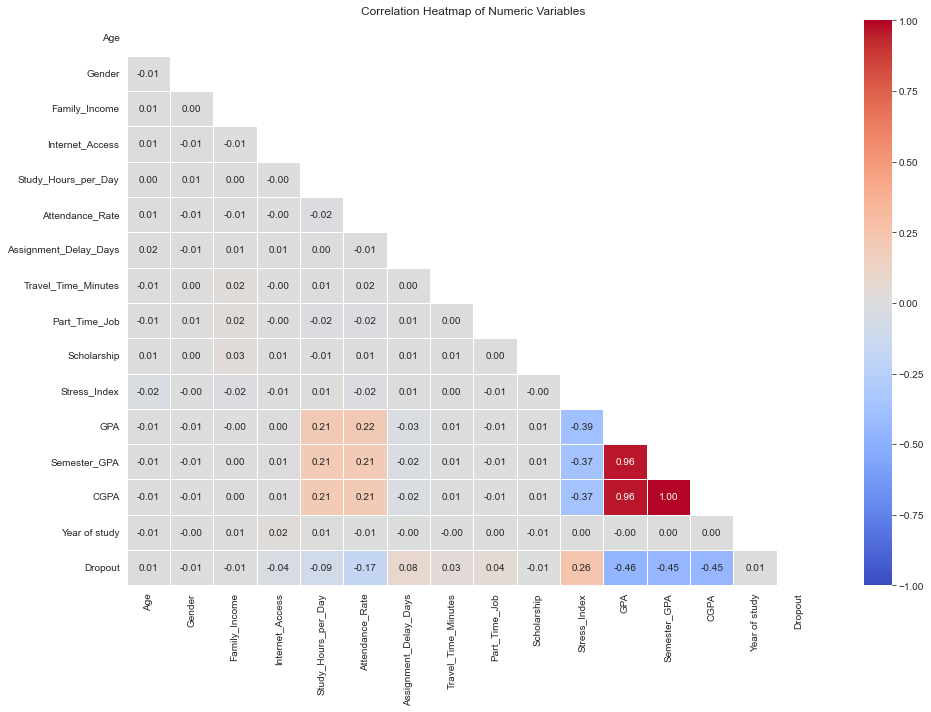

In [12]:
#Correlation heatmap to check columns with a high correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

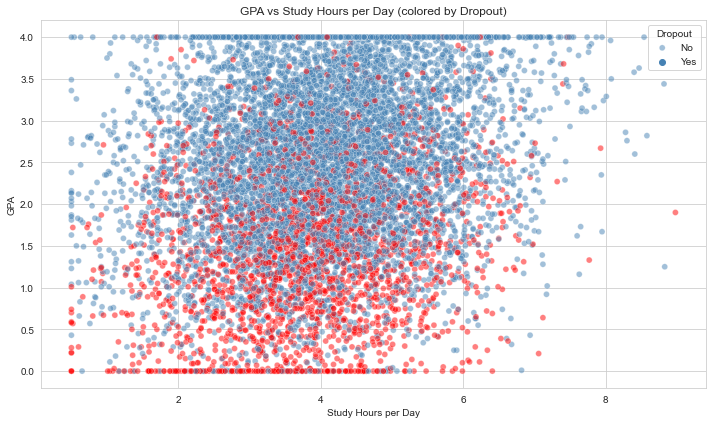

In [14]:
#GPA VS Study Hours per Day
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x='Study_Hours_per_Day', y='GPA',
    hue='Dropout', palette={0: 'steelblue', 1: 'red'},
    alpha=0.5
)
plt.title('GPA vs Study Hours per Day (colored by Dropout)')
plt.xlabel('Study Hours per Day')
plt.ylabel('GPA')
plt.legend(title='Dropout', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

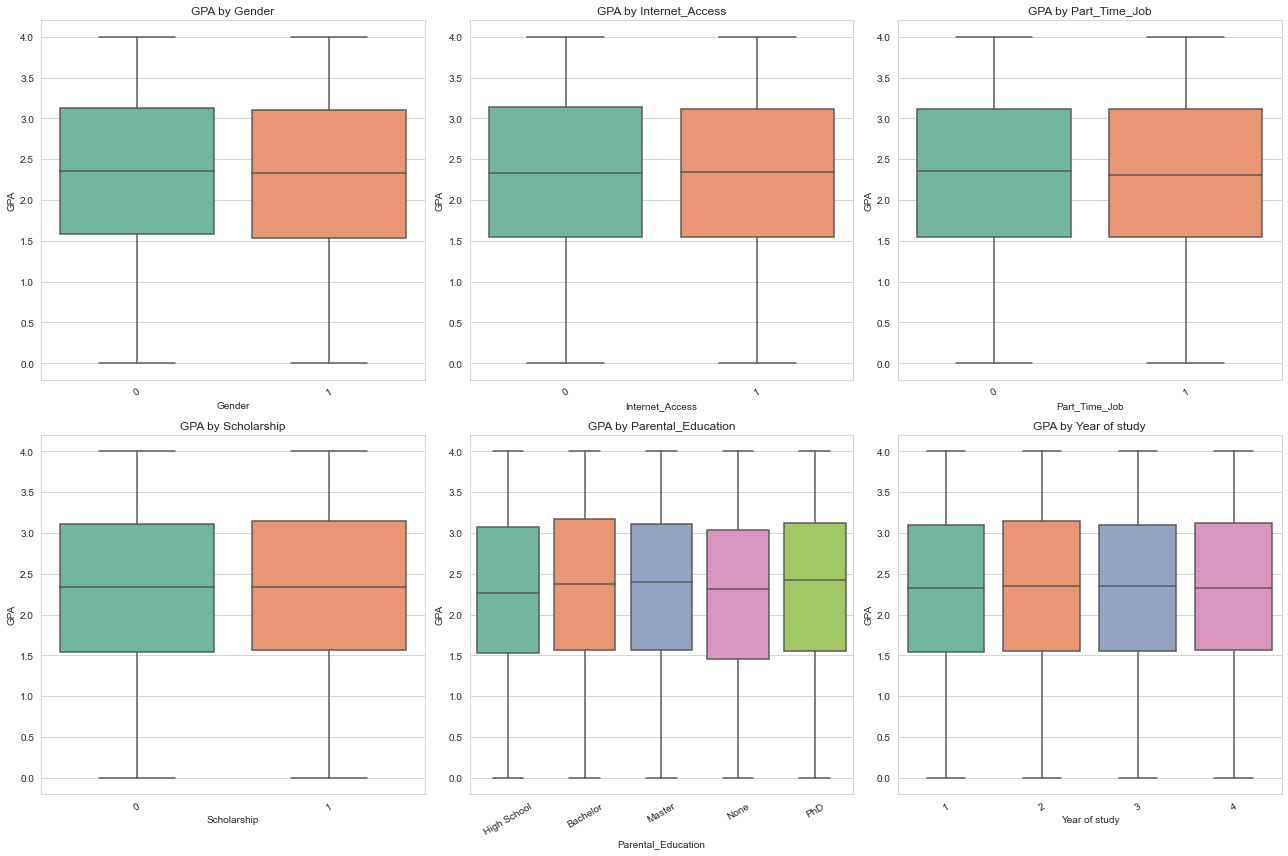

In [16]:
#GPA by Categorical groups box plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

group_cols = ['Gender', 'Internet_Access', 'Part_Time_Job',
              'Scholarship', 'Parental_Education', 'Year of study']

for ax, col in zip(axes.flatten(), group_cols):
    sns.boxplot(data=df, x=col, y='GPA', ax=ax, palette='Set2')
    ax.set_title(f'GPA by {col}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

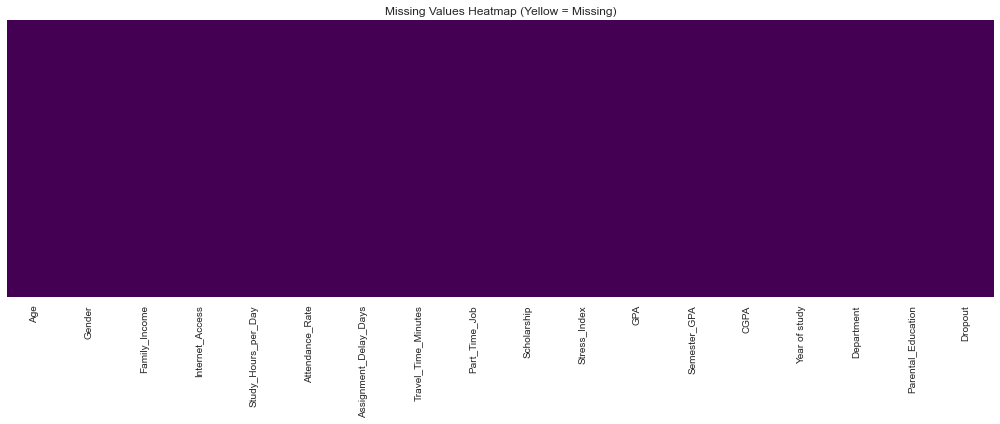

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [17]:
#Missing values heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

# Also print the summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
      [lambda x: x['Missing Count'] > 0])

From the plot above we can see we dont have any remaining missing values

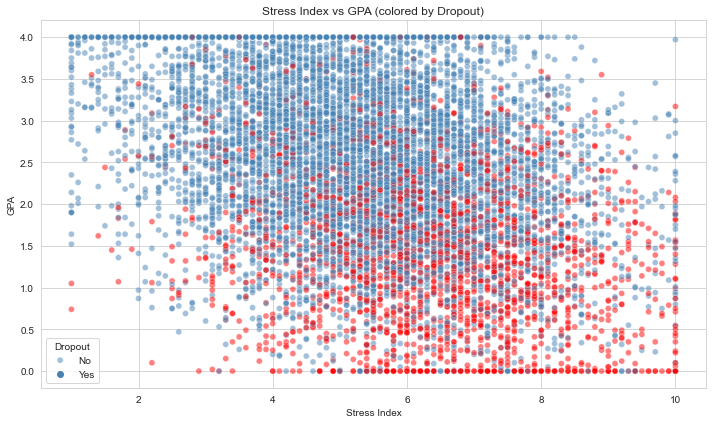

In [18]:
#Stress index vs GPA colored by dropout status
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x='Stress_Index', y='GPA',
    hue='Dropout', palette={0: 'steelblue', 1: 'red'},
    alpha=0.5
)
plt.title('Stress Index vs GPA (colored by Dropout)')
plt.xlabel('Stress Index')
plt.ylabel('GPA')
plt.legend(title='Dropout', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

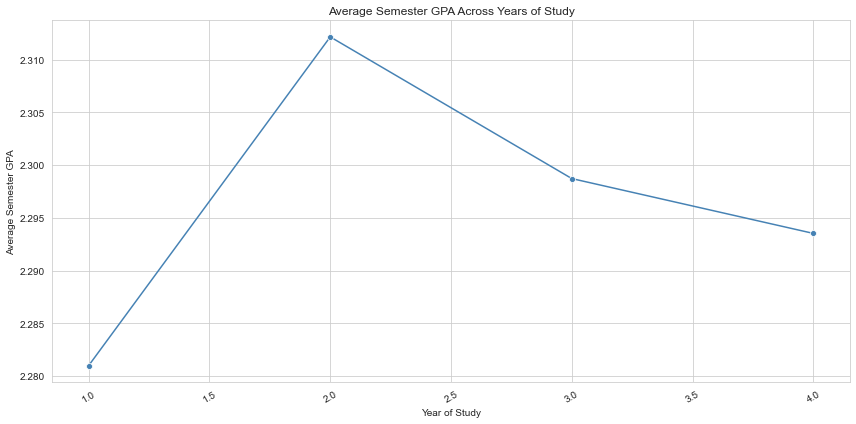

In [22]:
#GPA Trend over the years of study
plt.figure(figsize=(12, 6))
semester_gpa = df.groupby('Year of study')['Semester_GPA'].mean().reset_index()
sns.lineplot(data=semester_gpa, x='Year of study', y='Semester_GPA', 
             marker='o', color='steelblue')
plt.title('Average Semester GPA Across Years of Study')
plt.xlabel('Year of Study')
plt.ylabel('Average Semester GPA')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

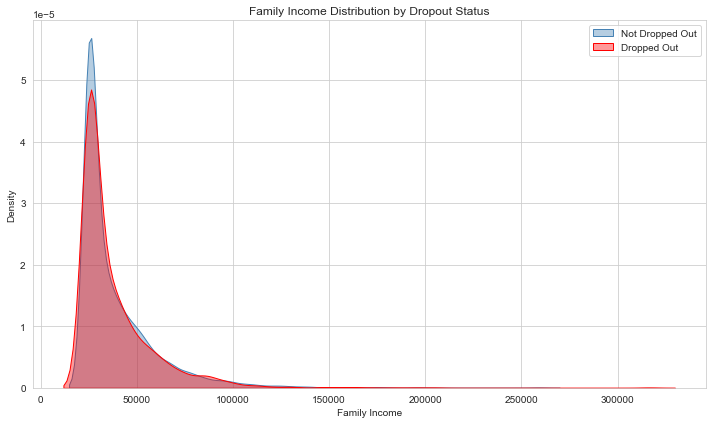

In [23]:
#Family income distribution colored by dropout status
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df[df['Dropout'] == 0], x='Family_Income',
    label='Not Dropped Out', color='steelblue', fill=True, alpha=0.4
)
sns.kdeplot(
    data=df[df['Dropout'] == 1], x='Family_Income',
    label='Dropped Out', color='red', fill=True, alpha=0.4
)
plt.title('Family Income Distribution by Dropout Status')
plt.xlabel('Family Income')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

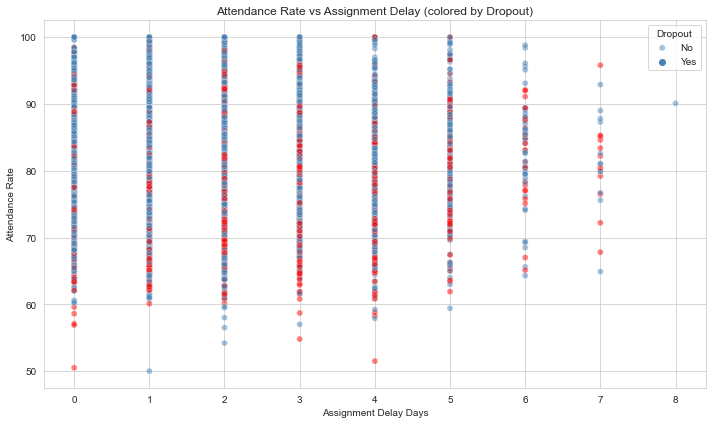

In [25]:
#Assignment vs Attendance Rate colored by dropout status
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x='Assignment_Delay_Days', y='Attendance_Rate',
    hue='Dropout', palette={0: 'steelblue', 1: 'red'},
    alpha=0.5
)
plt.title('Attendance Rate vs Assignment Delay (colored by Dropout)')
plt.xlabel('Assignment Delay Days')
plt.ylabel('Attendance Rate')
plt.legend(title='Dropout', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

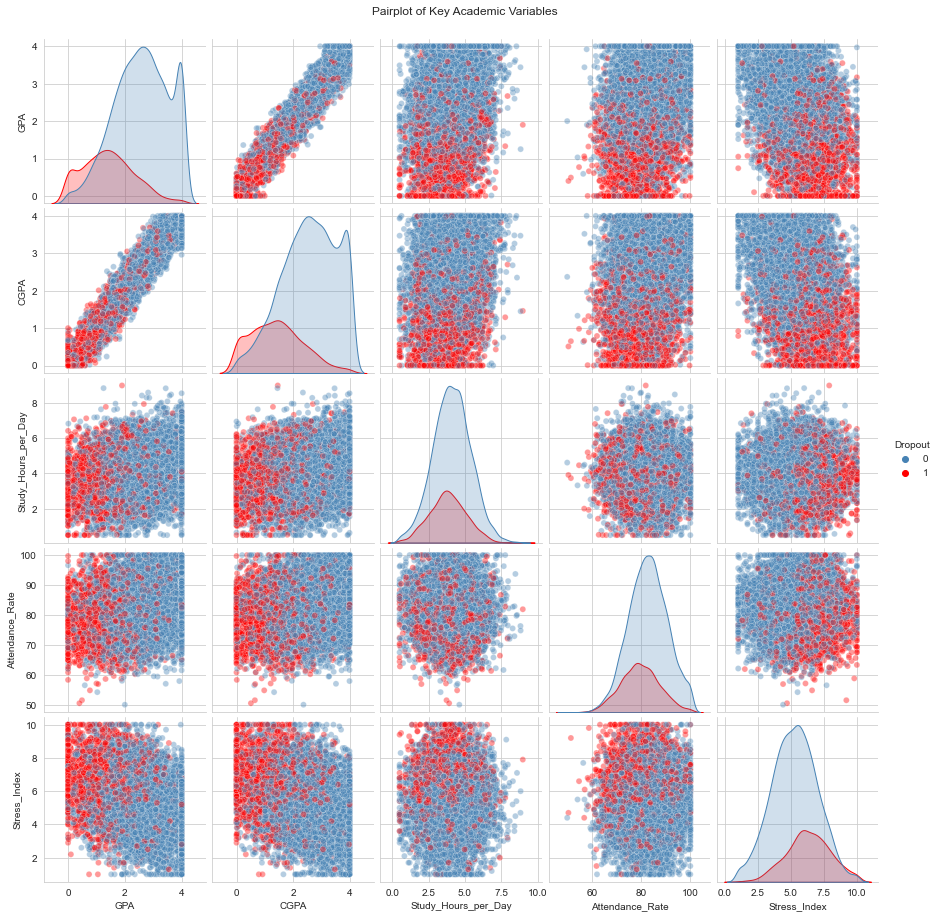

In [26]:
#Pairplot visual of key academic variables
key_cols = ['GPA', 'CGPA', 'Study_Hours_per_Day', 
            'Attendance_Rate', 'Stress_Index', 'Dropout']

sns.pairplot(
    df[key_cols].dropna(),
    hue='Dropout',
    palette={0: 'steelblue', 1: 'red'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4}
)
plt.suptitle('Pairplot of Key Academic Variables', y=1.02)
plt.show()